In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [12]:
df=pd.read_csv("/kaggle/input/datasets/divjotbedi/handling-mixed-variable-csv/Handling_Mixed_Variable.csv",usecols=['Cabin','Ticket number','number','Survived'])

In [14]:
df.head()

,Cabin,Ticket number,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [15]:
df['number'].unique()

array(['5', '3', '6', 'A', '7', '2', '4', '8', '1', 'C', 'B'],
      dtype=object)

In [22]:
df['number_numerical']=pd.to_numeric(df['number'],errors='coerce',downcast='integer')

In [23]:
df.head()

,Cabin,Ticket number,number,Survived,number_numerical
0,NaN,A/5 21171,5,0,5.0
1,C85,PC 17599,3,1,3.0
2,NaN,STON/O2. 3101282,6,1,6.0
3,C123,113803,3,1,3.0
4,NaN,373450,A,0,NaN


In [24]:
df['number_categorical']=np.where(df['number_numerical'].isnull(),df['number'],np.nan)

In [31]:
df.sample(20)

,Cabin,Ticket number,number,Survived,number_numerical,number_categorical
29,C85,4772073,4,0,4.0,NaN
19,D56,7712220,C,1,NaN,C
82,C123,S.O.C. 2564646,2,1,2.0,NaN
51,C85,C,B,0,NaN,B
40,NaN,A/4. 8437429,3,0,3.0,NaN
24,NaN,9324173,7,0,7.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
22,NaN,W./C. 5160230,4,0,4.0,NaN
85,NaN,W./C. 5010888,7,0,7.0,NaN
89,B96,943636,6,0,6.0,NaN


In [33]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'F33', 'D56', 'B28', 'G72', 'E101', 'A12',
       'B96'], dtype=object)

In [37]:
df['Ticket number'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       'A/5 7708870', 'PP 6068228', 'SC/Paris 1339687', '6220868',
       'PC 2872230', '9444066', 'C', 'D', '4508072', 'STON/O2. 8549432',
       'LINE', '7712220', '2810343', 'W./C. 5160230', 'A', '9324173',
       '3474754', 'C.A. 3861684', 'B', '4772073', '1682524', '1008841',
       '4773212', 'A/5 9718032', 'A/4. 8437429', 'STON/O2. 1150597',
       '1317071', '8587336', 'SC/Paris 2647552', 'PC 9282552', '4528914',
       'STON/O2. 9154486', 'SC/Paris 6118837', 'W./C. 6908400',
       'A/4. 5867294', '5899667', 'W./C. 5267630', '6951696', '6461002',
       '106810', '5506444', '2946949', 'CA. 7972465', 'A/5 1789238',
       'A/4. 8911914', 'S.O.C. 2564646', '7916912', 'W./C. 5010888',
       'S.O.C. 8148720', 'A/4. 2142239', '554696', '943636', '6460682',
       'A/5 9050949', 'A/5 521596', 'STON/O2. 7946036', 'W./C. 2816034',
       'A/5 5234774', 'PP 4075336', '5824909', '6176506'], dtype=object)

In [38]:
df['Cabin_numerical']=df['Cabin'].str.extract('(\d+)')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_57/3135295230.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Cabin_numerical']=df['Cabin'].str.extract('(\d+)')


In [39]:
df.head()

,Cabin,Ticket number,number,Survived,number_numerical,number_categorical,Cabin_numerical
0,NaN,A/5 21171,5,0,5.0,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123
4,NaN,373450,A,0,NaN,A,NaN


In [40]:
df['Cabin_categorical']=df['Cabin'].str[0]

In [42]:
df.head(10)

,Cabin,Ticket number,number,Survived,number_numerical,number_categorical,Cabin_numerical,Cabin_categorical
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN
5,F33,A/5 7708870,7,0,7.0,NaN,33,F
6,NaN,PP 6068228,2,0,2.0,NaN,NaN,NaN
7,NaN,SC/Paris 1339687,2,1,2.0,NaN,NaN,NaN
8,D56,6220868,6,0,6.0,NaN,56,D
9,NaN,PC 2872230,4,0,4.0,NaN,NaN,NaN


<Axes: xlabel='Cabin_categorical'>

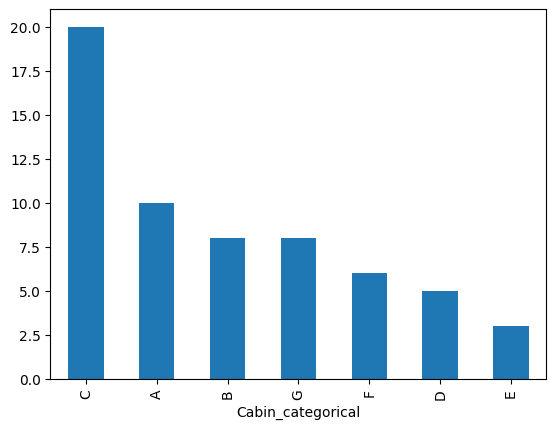

In [45]:
df['Cabin_categorical'].value_counts().plot(kind='bar')

In [57]:
df['Ticket number'].apply(lambda s:s.split())

0            [A/5, 21171]
1             [PC, 17599]
2     [STON/O2., 3101282]
3                [113803]
4                [373450]
             ...         
95         [A/5, 5234774]
96          [PP, 4075336]
97                    [A]
98              [5824909]
99              [6176506]
Name: Ticket number, Length: 100, dtype: object

In [58]:
df['Ticket number'].apply(lambda s:s.split()[0])

0          A/5
1           PC
2     STON/O2.
3       113803
4       373450
        ...   
95         A/5
96          PP
97           A
98     5824909
99     6176506
Name: Ticket number, Length: 100, dtype: object

In [59]:
df['Ticket number'].apply(lambda s:s.split()[-1])

0       21171
1       17599
2     3101282
3      113803
4      373450
       ...   
95    5234774
96    4075336
97          A
98    5824909
99    6176506
Name: Ticket number, Length: 100, dtype: object

In [50]:
df['Ticket_numberical']=df['Ticket number'].apply(lambda s:s.split()[-1])
df['Ticket_numberical']=pd.to_numeric(df['Ticket_numberical'],errors='coerce',downcast='integer')

In [54]:
df.head(15)

,Cabin,Ticket number,number,Survived,number_numerical,number_categorical,Cabin_numerical,Cabin_categorical,Ticket_numberical
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0
3,C123,113803,3,1,3.0,NaN,123,C,113803.0
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0
5,F33,A/5 7708870,7,0,7.0,NaN,33,F,7708870.0
6,NaN,PP 6068228,2,0,2.0,NaN,NaN,NaN,6068228.0
7,NaN,SC/Paris 1339687,2,1,2.0,NaN,NaN,NaN,1339687.0
8,D56,6220868,6,0,6.0,NaN,56,D,6220868.0
9,NaN,PC 2872230,4,0,4.0,NaN,NaN,NaN,2872230.0


In [55]:
df['Ticket_categorical']=df['Ticket number'].apply(lambda s:s.split()[0])
df['Ticket_categorical']=np.where(df['Ticket_categorical'].str.isdigit(),np.nan,df['Ticket_categorical'])

In [56]:
df.head(15)

,Cabin,Ticket number,number,Survived,number_numerical,number_categorical,Cabin_numerical,Cabin_categorical,Ticket_numberical,Ticket_categorical
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,F33,A/5 7708870,7,0,7.0,NaN,33,F,7708870.0,A/5
6,NaN,PP 6068228,2,0,2.0,NaN,NaN,NaN,6068228.0,PP
7,NaN,SC/Paris 1339687,2,1,2.0,NaN,NaN,NaN,1339687.0,SC/Paris
8,D56,6220868,6,0,6.0,NaN,56,D,6220868.0,NaN
9,NaN,PC 2872230,4,0,4.0,NaN,NaN,NaN,2872230.0,PC
